# Лабораторная работа 1 
Задача о падении тела. Построение графиков функций

Хмельницкий Станислав Николаевич 14.02.2026

## Задание 1.1. Задача о падении тела

In [5]:
import math

In [6]:
math.sin(math.pi/2)

1.0

In [7]:
import numpy as np

In [8]:
import matplotlib.pyplot as plt

In [9]:
import scipy.constants as const

In [10]:
import sympy 

In [11]:
h_end = 3.0E+0 # вертикальная составляющая положения тела в конечный момент движ
T = 3.0  # время полета
s_end = 5.0e0 # горизонтальное перемещение тела за время полета
h_start = 1 # вертикальная составляющая положения тела в момент запуска      

In [12]:
h_start  # переменная не отобразится
h_end # переменная отобразится

3.0

In [13]:
print(h_start,h_end)

1 3.0


In [14]:
g = const.g
g, const.unit('standard acceleration of gravity')

(9.80665, 'm s^-2')

In [15]:
step = 0.01
t_list = [0 + i*step for i in range(int(T/step))]
t_array = np.arange(0,T,step)

In [16]:
#?range

In [17]:
#?np.arange

In [18]:
v0_x = s_end/T
v0_x

1.6666666666666667

In [19]:
v0_y = (h_end-h_start+g/2*T**2)/T
v0_y

15.376641666666666

In [20]:
alpha = math.atan(v0_y/v0_x)
alpha, math.degrees(alpha)

(1.462828312588189, 83.81388846354714)

In [21]:
f's_x(t) = {v0_x} t'

's_x(t) = 1.6666666666666667 t'

In [22]:
f's_y(t) = {h_start} + {v0_y:.6} t - {g:.6}/2*t\N{superscript two}'

's_y(t) = 1 + 15.3766 t - 9.80665/2*t²'

In [23]:
t_list, t_array; # символ ; в конце выражения предотвращает вывод результата 

In [24]:
s_x_list = [v0_x*t for t in t_list]
s_y_list = [h_start+v0_y*t-g*t**2/2 for t in t_list]

In [25]:
s_x_array = v0_x*t_array
s_y_array = h_start+v0_y*t_array-g*t_array**2/2

(np.float64(0.0), np.float64(5.0), np.float64(0.0), np.float64(14.0))

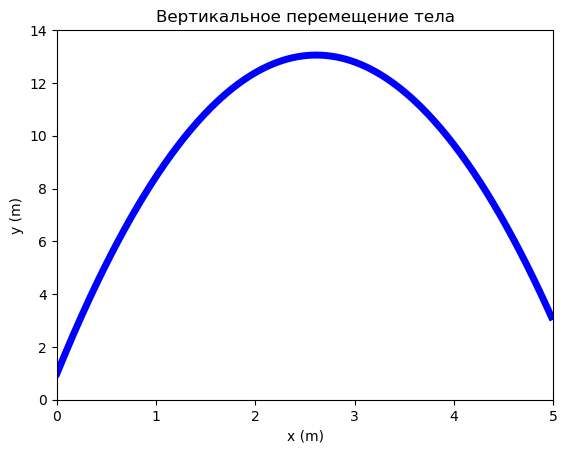

In [26]:
plt.figure()
plt.plot(s_x_list,s_y_list,'b-',lw=5)
plt.title('Вертикальное перемещение тела')
plt.xlabel('x (m)'); plt.ylabel('y (m)') # символ ; позволяет записывать несколь

plt.axis([0, s_end, 0, h_end+11])

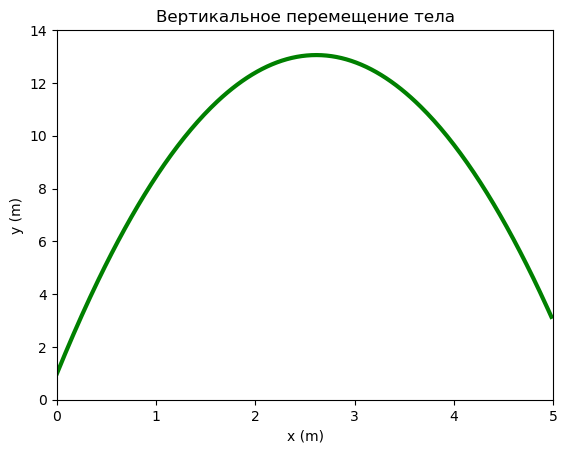

In [27]:
plt.figure()
plt.plot(s_x_array,s_y_array,color='green',lw=3)
plt.title('Вертикальное перемещение тела')
plt.xlabel('x (m)'); plt.ylabel('y (m)')
# альтернативный синтаксис для установки пределов по осям
plt.xlim(0, s_end)
plt.ylim(0, h_end+11);

In [28]:
## Задание 1.2. Определение момента времени касания телом земли

In [29]:
t = sympy.symbols('t')
result = sympy.solve(h_start+v0_y*t-g*t**2/2, t)

In [30]:
t_star_exact = result[-1]
t_star_exact

3.19970039267921

In [31]:
t_stop = T+1
t_part = [i*step for i in range(int(t_stop/step))]

In [32]:
def s_y(t):
    return h_start+v0_y*t-g*t**2/2

In [33]:
a = 0
x = 1
for i in t_part:
    
    if x*s_y(i)<0:
        a = i
        break
    x = i
a

3.2

In [34]:
# ?sympy.solve


In [35]:
## Задание 1.3. Построение секущей,касательной и нормали к графику функции

In [36]:
p_start = np.array([s_x_array[0],s_y_array[0]])
p_end = np.array([s_x_array[-1],s_y_array[-1]])
p_start, p_end

(array([0., 1.]), array([4.98333333, 3.13994275]))

In [37]:
a = p_end-p_start

In [38]:
p = [p_start + a*t for t in [-1, 2]] 
p = np.array(p)

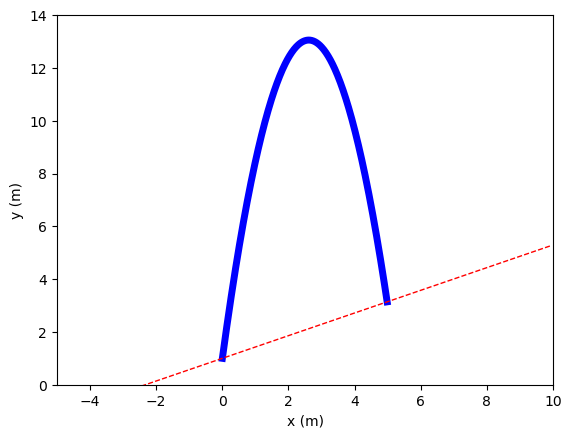

In [39]:
fig = plt.figure()
plt.plot(s_x_array,s_y_array,'b-',lw=5)
plt.plot(p[:,0],p[:,1],'--',color='red',lw=1) # обратите внимание не специальную
plt.xlabel('x (m)'); plt.ylabel('y (m)')
plt.axis([-5, s_end+5, 0, h_end+11]);

In [40]:
k = math.tan(alpha)
kos = [(t,k*(t-s_x_array[0])+s_y_array[0]) for t in [-1,4]]
kos = np.array(kos)

In [41]:
vec = np.array([k,-1])
n = [p_start + vec*t for t in [-1,3]]
n = np.array(n)


(np.float64(-5.0), np.float64(10.0), np.float64(0.0), np.float64(14.0))

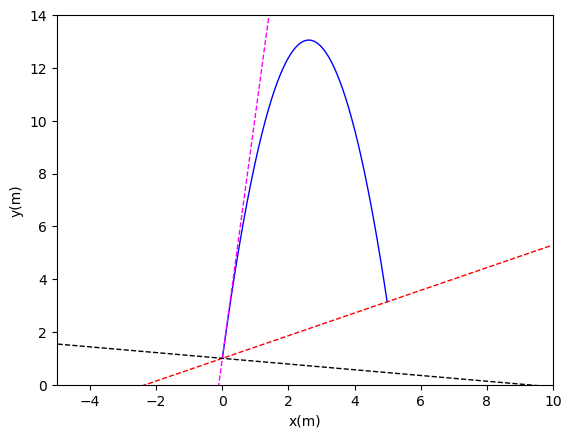

In [51]:
fig = plt.figure()
plt.plot(s_x_array, s_y_array,'-b',lw=1)
plt.plot(p[:,0], p[:,1],'--',color = 'red',lw=1)
plt.xlabel('x(m)');plt.ylabel('y(m)')
plt.plot(kos[:,0],kos[:,1],'--',color='magenta',lw=1)
plt.plot(n[:,0],n[:,1],'--',color='black', lw=1)

plt.axis([-5,s_end+5,0, h_end+11])

In [43]:
## Задание 1.4. Построение графиков функций

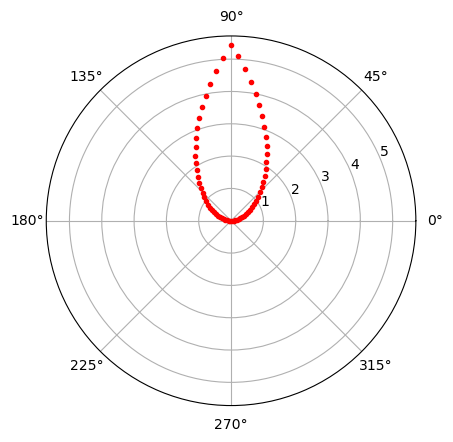

In [44]:
plt.figure()
# установка способа отображения осей
plt.axes(projection='polar')
# подготовка данных
phi = np.arange(-np.pi/2, np.pi/2, 0.05)
r = phi**3+phi
# построение графика
plt.plot(phi + (r<0)*np.pi,abs(r),'r.');

1 Вариант:

ρ=3asin(φ)cos(φ)sin3(φ)+cos3(φ),a∈R

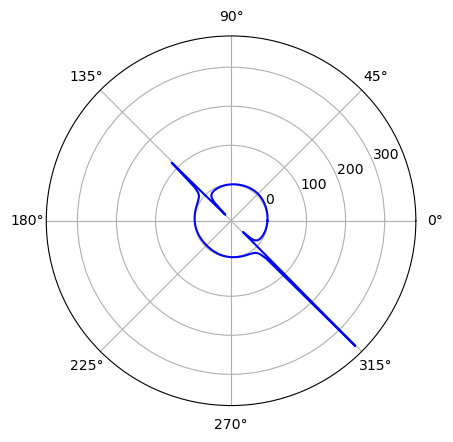

In [45]:
plt.figure()
plt.axes(projection='polar')
phi = np.linspace(0, 2*np.pi, 200)
a = 2
f = (3*a*np.sin(phi)*np.cos(phi))/(((np.sin(phi))**3)+(np.cos(phi))**3)
plt.plot(phi,f,color='blue')

x=(3t^2+1)/3t^3 
y=sin(t^3/3+t)



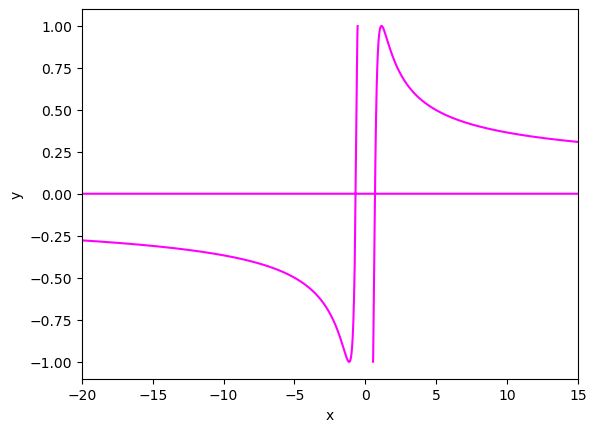

In [50]:
plt.figure()
plt.axes(projection=None)

t = np.arange(-2,2,0.001)
x = (3*(t**2)+1)/(3*t**3)
y = np.sin(((t**3)/(3))+t)


plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-20, 15)
plt.plot(x,y,'Magenta')
